In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("Titanic-Dataset.csv",usecols=['Age','Fare','Survived'])
df['Age'].fillna(df['Age'].mean(),inplace=True)
print(df.isnull().sum())
df.head()
df['Age'].shape

Survived    0
Age         0
Fare        0
dtype: int64


(891,)

C:\Users\ARPIT\AppData\Local\Temp\ipykernel_16436\3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

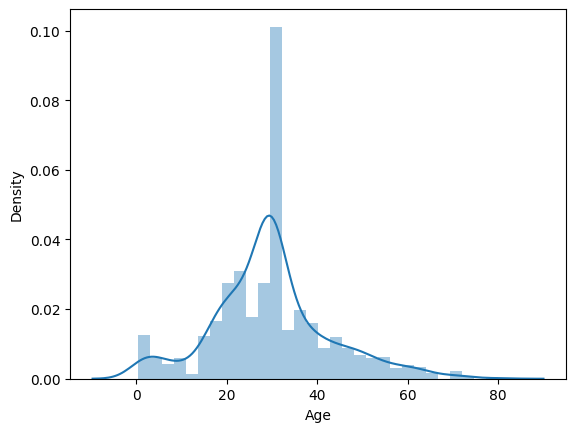

In [3]:
sns.distplot(df['Age'])

C:\Users\ARPIT\AppData\Local\Temp\ipykernel_16436\3425841524.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

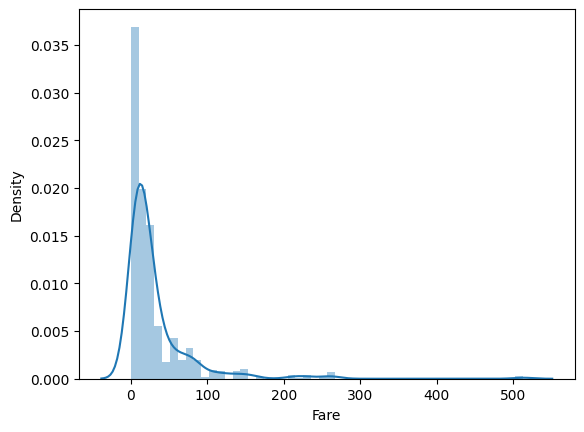

In [ ]:
# It is right skewed
sns.distplot(df['Fare'])

In [5]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [6]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()
lr_trans=LogisticRegression()
df_trans=DecisionTreeClassifier()

In [7]:
# Before Transformation
lr.fit(x_train,y_train)
dt.fit(x_train,y_train)
pred_lr=lr.predict(x_test)
pred_dt=dt.predict(x_test)

In [8]:
#After Transformation
trf=FunctionTransformer(func=np.log1p)
x_train_trans=trf.fit_transform(x_train)
x_test_trans=trf.transform(x_test)
lr_trans.fit(x_train_trans,y_train)
df_trans.fit(x_train_trans,y_train)
pred_lr_trans=lr_trans.predict(x_test_trans)
pred_df_trans=df_trans.predict(x_test_trans)

In [9]:
print("Accuracy Score :",accuracy_score(y_test,pred_lr))
print("Accuracy Score :",accuracy_score(y_test,pred_dt))
print("Accuracy Score :",accuracy_score(y_test,pred_lr_trans))
print("Accuracy Score :",accuracy_score(y_test,pred_df_trans))

Accuracy Score : 0.6480446927374302
Accuracy Score : 0.6480446927374302
Accuracy Score : 0.6815642458100558
Accuracy Score : 0.6927374301675978


C:\Users\ARPIT\AppData\Local\Temp\ipykernel_16436\1775241904.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_trans['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

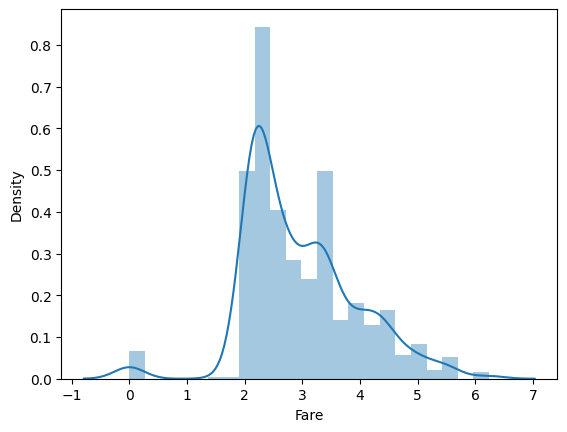

In [10]:
sns.distplot(x_train_trans['Fare'])